# AdaBoost (Adaptive Boosting): A Step-by-Step Tutorial

**Goal:** Learn how AdaBoost works and how to use it in Python with clear, incremental steps:
1. Generate a toy dataset and visualize it.
2. Train a **Decision Stump** (baseline).
3. Train **AdaBoost** with multiple stumps.
4. Compare train/test accuracy.
5. Visualize decision boundaries.
6. Study how performance evolves with the number of estimators.


## 1. Setup

We will use `scikit-learn` for the models and `matplotlib` for plotting.


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Show library versions (useful for debugging)
import sklearn, sys
print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)


Python: 3.13.5
scikit-learn: 1.6.1


## 2. Create and Visualize a Toy Dataset

We will use the classic **two-moons** dataset, which is non-linearly separable and a good testbed for boosting.


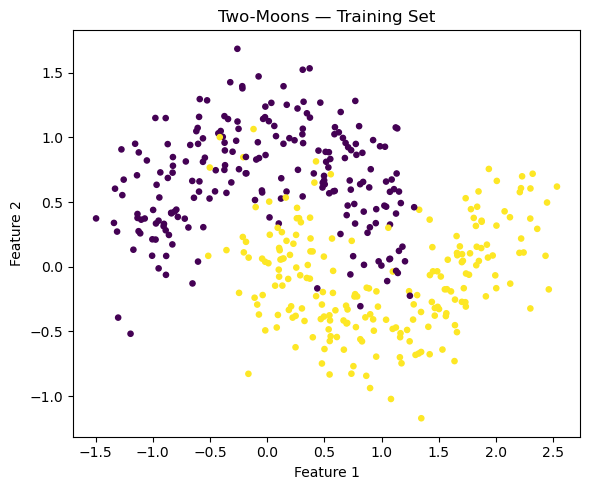

In [2]:
# Generate data
X, y = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Quick scatter plot of the training set
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=14)
plt.title('Two-Moons — Training Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()


## 3. Baseline: Decision Stump

A **Decision Stump** is a decision tree with `max_depth=1`. It is a very weak learner and will serve as our baseline.


In [3]:
# Train a single decision stump
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
stump.fit(X_train, y_train)

# Evaluate
stump_train_acc = accuracy_score(y_train, stump.predict(X_train))
stump_test_acc  = accuracy_score(y_test,  stump.predict(X_test))

print('Decision Stump Accuracy — Train:', round(stump_train_acc, 4))
print('Decision Stump Accuracy — Test :', round(stump_test_acc,  4))


Decision Stump Accuracy — Train: 0.831
Decision Stump Accuracy — Test : 0.85


## 4. Train AdaBoost

AdaBoost trains weak learners **sequentially**, re-weighting samples to focus on previously misclassified points.

- We will use decision stumps as base estimators.
- We set `n_estimators` and `learning_rate` to reasonable defaults.


In [4]:
# Version-safe constructor: try new 'estimator=' first; fall back to 'base_estimator=' if needed
def make_adaboost_stumps(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE):
    try:
        # Newer scikit-learn
        return AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=random_state),
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_state
        )
    except TypeError:
        # Older scikit-learn
        return AdaBoostClassifier(
            base_estimator=DecisionTreeClassifier(max_depth=1, random_state=random_state),
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_state
        )

ada = make_adaboost_stumps(n_estimators=200, learning_rate=0.5)
ada.fit(X_train, y_train)

ada_train_acc = accuracy_score(y_train, ada.predict(X_train))
ada_test_acc  = accuracy_score(y_test,  ada.predict(X_test))

print('AdaBoost Accuracy — Train:', round(ada_train_acc, 4))
print('AdaBoost Accuracy — Test :', round(ada_test_acc,  4))


AdaBoost Accuracy — Train: 0.9548
AdaBoost Accuracy — Test : 0.9111


## 5. Compare Accuracies

Let's summarize model performance side by side.


In [5]:
acc_df = pd.DataFrame({
    'Model': ['Decision Stump (max_depth=1)', 'AdaBoost (stumps)'],
    'Train Accuracy': [stump_train_acc, ada_train_acc],
    'Test Accuracy' : [stump_test_acc,  ada_test_acc]
})
acc_df


,Model,Train Accuracy,Test Accuracy
0,Decision Stump (max_depth=1),0.830952,0.850000
1,AdaBoost (stumps),0.954762,0.911111


## 6. Visualize Decision Boundaries

The plots below show how a single stump draws a very **coarse** boundary, while AdaBoost creates a much more **refined** boundary by combining many stumps.


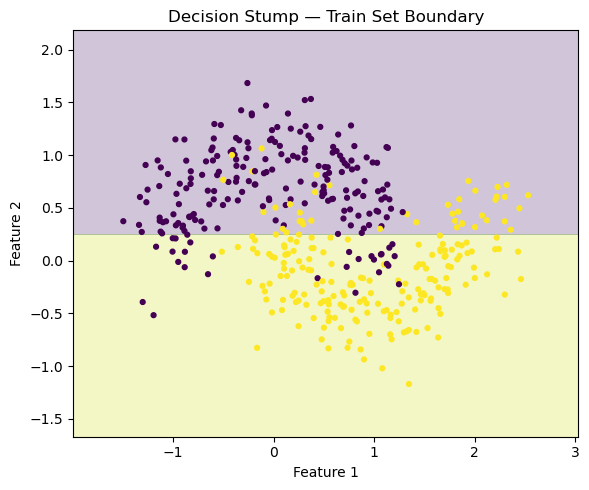

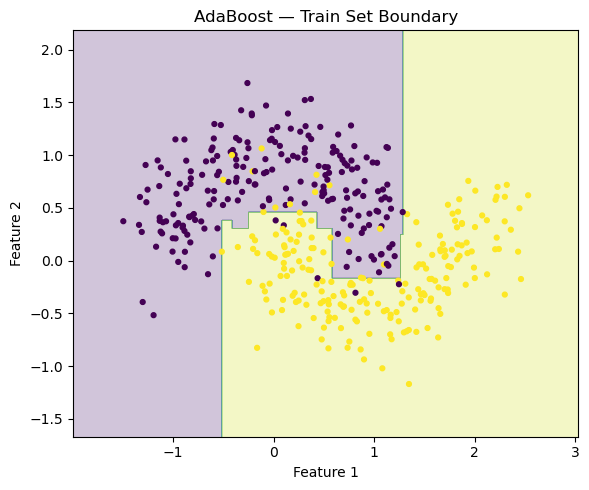

In [6]:
def plot_decision_boundary(model, X, y, title):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # One chart per figure; do not set any specific colors
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

# Train-set boundaries
plot_decision_boundary(stump, X_train, y_train, 'Decision Stump — Train Set Boundary')
plot_decision_boundary(ada,   X_train, y_train, 'AdaBoost — Train Set Boundary')


## 7. Test Accuracy vs. Number of Estimators

AdaBoost allows staged predictions as it adds more weak learners.  
We can visualize how test accuracy evolves with the number of estimators.


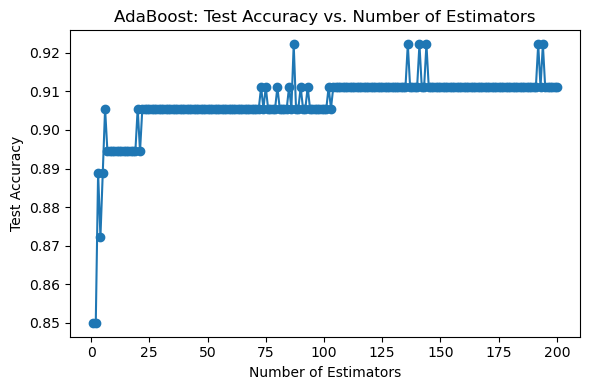

In [7]:
test_scores = []
for y_pred in ada.staged_predict(X_test):
    test_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(test_scores) + 1), test_scores, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost: Test Accuracy vs. Number of Estimators')
plt.tight_layout()
plt.show()


## 8. Optional: Classification Report

A quick breakdown of precision/recall/F1 for the AdaBoost model.


In [8]:
print(classification_report(y_test, ada.predict(X_test)))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        90
           1       0.93      0.89      0.91        90

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180



## 9. Key Takeaways

- **AdaBoost** combines many weak learners to form a strong classifier.
- It **focuses** on previously misclassified samples by reweighting the training data.
- With simple decision stumps, AdaBoost can learn **non-linear** decision boundaries.
- It is **sensitive to outliers** and inherently **sequential** (hard to parallelize).
- Tune `n_estimators` and `learning_rate` for a good bias–variance tradeoff.
